## Part 01

In [251]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib import figure
from matplotlib.pyplot import xlabel

df = pd.read_csv(r"C:\Users\User\PyCharmMiscProject\Datasets\Superstore_Data.csv")
print(df.head())

   Order Date     Sales    Profit
0  17-10-2013  5175.171   919.971
1  07-11-2011  1822.080   564.840
2  14-04-2012  5244.840   996.480
3  06-06-2013  3701.520  1036.080
4  25-02-2012  1878.720   582.360


In [252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  5699 non-null   object 
 1   Sales       5699 non-null   float64
 2   Profit      5699 non-null   float64
dtypes: float64(2), object(1)
memory usage: 133.7+ KB


In [253]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

In [254]:
df.dtypes

Order Date    datetime64[ns]
Sales                float64
Profit               float64
dtype: object

In [209]:
df.sort_values(by=["Order Date"], inplace=True)
df.head()

,Order Date,Sales,Profit
5073,2011-01-01,55.242,15.342
3056,2011-01-01,120.366,36.036
4083,2011-01-01,113.670,37.770
424,2011-01-03,912.456,-319.464
5517,2011-01-03,6.006,0.546


In [210]:
df.tail()#so the data is 4 years

,Order Date,Sales,Profit
4875,2014-12-30,8.5407,2.3607
1455,2014-12-30,255.2850,-47.6550
4345,2014-12-30,10.8540,-6.6960
1804,2014-12-31,300.2400,84.0600
3956,2014-12-31,39.6000,6.6600


In [212]:
df.set_index("Order Date", inplace=True)#Explicit index when we add new index and implicit is when index is already exist index
df

,Sales,Profit
Order Date,,
2011-01-01,55.2420,15.3420
2011-01-01,120.3660,36.0360
2011-01-01,113.6700,37.7700
2011-01-03,912.4560,-319.4640
2011-01-03,6.0060,0.5460
...,...,...
2014-12-30,8.5407,2.3607
2014-12-30,255.2850,-47.6550
2014-12-30,10.8540,-6.6960


In [213]:
df.loc['2011-01-01'] #explicit index

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770


In [214]:
df.iloc[0:3] #implicit index


,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770


In [215]:
df["2011-01" : "2011-02"].sum()

Sales     28622.5713
Profit     2330.1513
dtype: float64

In [216]:
df["2011" : "2012"].sum()

Sales     704488.6593
Profit     85321.5993
dtype: float64

In [217]:
# the granularity rule => the more agg of forecast are more accurate it be
# always study data in weeks wise -> month wise -> year wise more agg more stable
# to have a big picture of our data

In [218]:
df = df.groupby(pd.Grouper(freq="ME")).sum()


In [219]:
df.drop(columns= "Profit", inplace=True)

In [220]:
df

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723
2011-06-30,27260.0196
2011-07-31,15842.8317
2011-08-31,22012.2366
2011-09-30,34613.1849


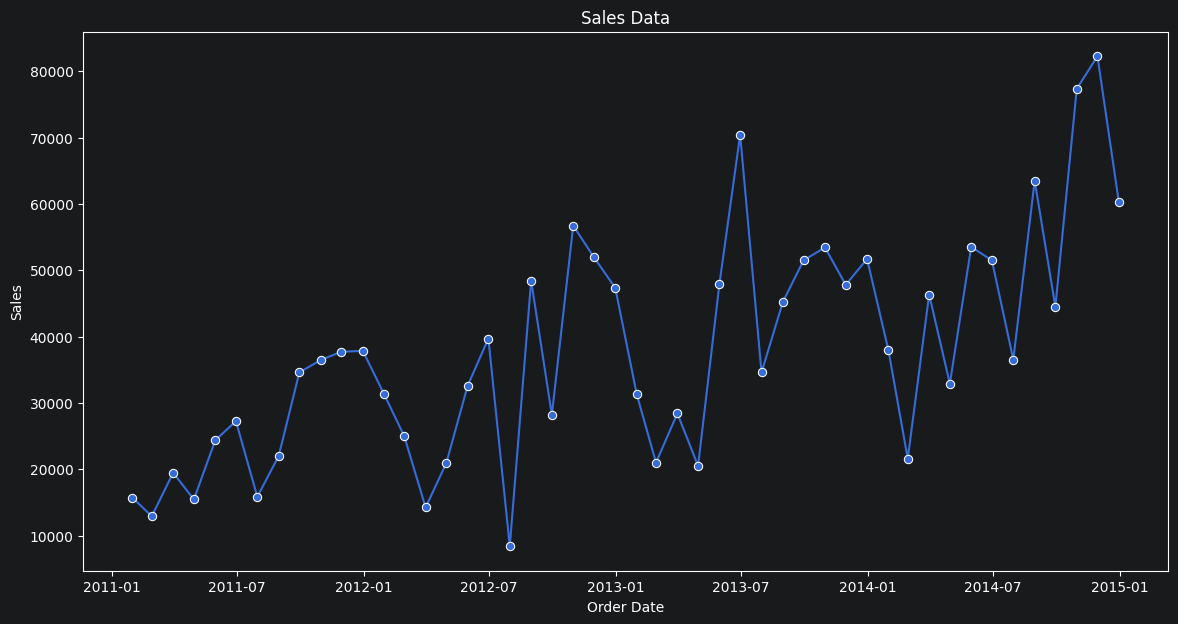

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(14,7))
sns.lineplot(x="Order Date", y="Sales", data=df, marker= 'o')
plt.title("Sales Data")
plt.show()

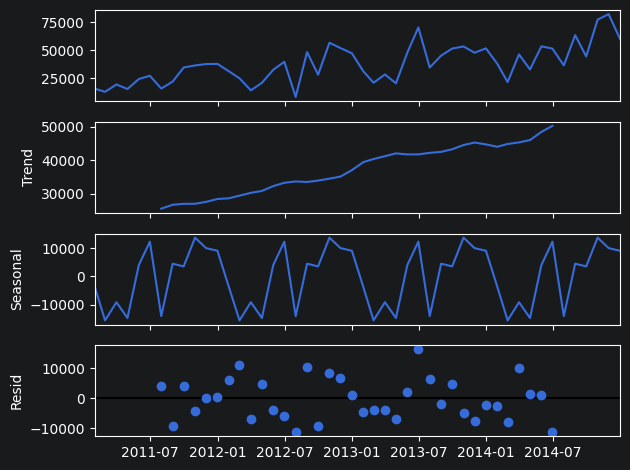

In [222]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_plot = seasonal_decompose(df).plot()
decompose_plot;

### We have 4 main properties of Time Series Forecasting
- Time Series : Always have some kind of trends (increasing or decreasing)
- Seasonality : Repeating pattern at a constant time interval
- Cyclic nature : A repeating pattern at random time intervals
- Noise : Something Random, you can't explain


every time series data whether stationary TS data or non-stationary TS data

## Part 02 (Stationary Analysis) Hypothesis test

In [223]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Sales"])
p_value = result[1]#second value is the p-value and is not less then 0.5 %
if p_value < 0.05:
    print(f"{result[1]} is less than 0.05 and it's Stationary data, Null Hypothesis is False")
else:
    print(f"{result[1]} is more than 0.05 and it's non-Stationary data, Null Hypothesis is True")

0.1987628396941693 is more than 0.05 and it's non-Stationary data, Null Hypothesis is True


## Part 03 Time Series Transformation to stationary

#### By data we came to know that we have three problems
- Fix variance
- Fix mean
- Fix seasonality

In [224]:
# For Variance fix we need to choose either Box-Cox or Log Transformation for that check lambda
from scipy.stats import boxcox
y_box_cox, lam = boxcox(df["Sales"])
lam # lambda = 0.46 which mean we can use box-cox instead of log transformation

np.float64(0.4604225316383878)

| λ value | Meaning                |
| ------- |------------------------|
| ≈ 0     | Log transform          |
| ≈ 0.5   | Box-cox                |
| ≈ 1     | No transformation      |
| < 0     | Strong compression +1  |


1) Box-Cox → fix variance
2) First difference → remove trend
3) Seasonal difference → remove seasonality

#### 1) Box-Cox

In [225]:
from scipy.stats import boxcox
y_box_cox, lam = boxcox(df["Sales"])
df["Sales"] = y_box_cox

In [226]:
df['Sales']

Order Date
2011-01-31    183.556898
2011-02-28    167.503841
2011-03-31    202.845370
2011-04-30    182.072767
2011-05-31    225.064508
2011-06-30    237.192514
2011-07-31    184.268937
2011-08-31    214.750214
2011-09-30    265.013359
2011-10-31    271.526740
2011-11-30    275.808341
2011-12-31    276.229998
2012-01-31    252.846206
2012-02-29    227.781357
2012-03-31    175.340823
2012-04-30    209.756517
2012-05-31    257.774225
2012-06-30    282.458124
2012-07-31    136.959576
2012-08-31    309.743458
2012-09-30    240.931092
2012-10-31    333.296823
2012-11-30    319.987437
2012-12-31    306.458821
2013-01-31    253.024048
2013-02-28    210.097820
2013-03-31    241.808209
2013-04-30    207.798008
2013-05-31    308.360806
2013-06-30    368.406079
2013-07-31    264.955206
2013-08-31    300.103194
2013-09-30    318.689117
2013-10-31    324.184135
2013-11-30    307.863220
2013-12-31    319.274669
2014-01-31    276.491788
2014-02-28    212.799212
2014-03-31    303.429378
2014-04-30    

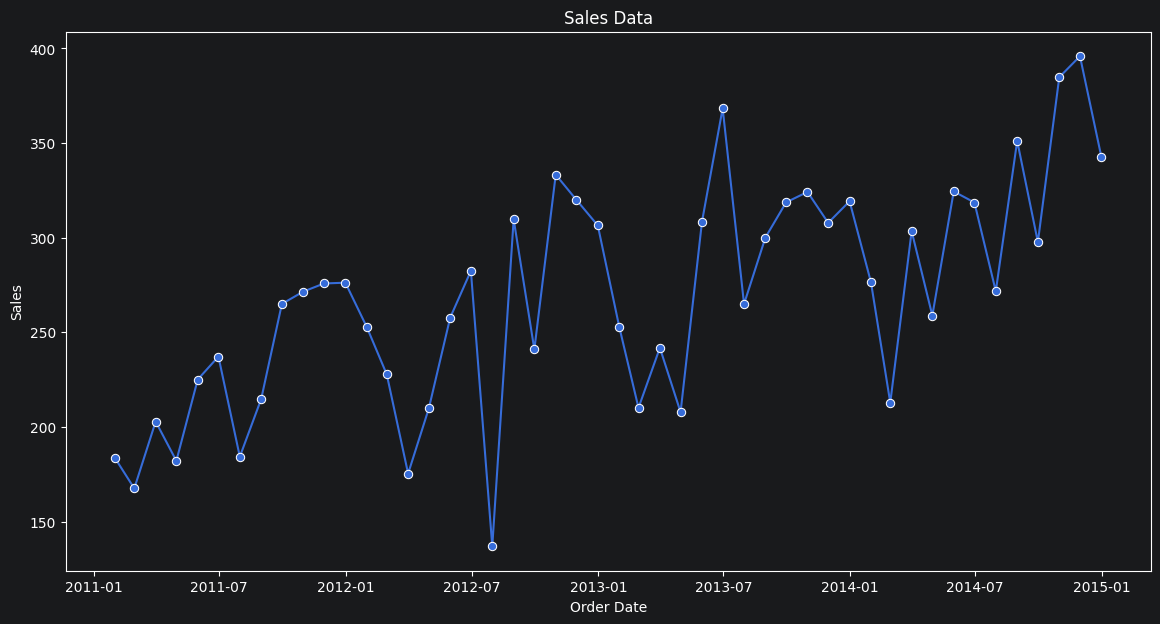

In [227]:
plt.figure(figsize=(14,7))
sns.lineplot(x="Order Date", y="Sales", data=df, marker= 'o')
plt.title("Sales Data")
plt.show()

#### 2) Differencing

In [228]:
diff1 = df["Sales"].diff()
diff1 # one NaN value

Order Date
2011-01-31           NaN
2011-02-28    -16.053057
2011-03-31     35.341529
2011-04-30    -20.772603
2011-05-31     42.991741
2011-06-30     12.128005
2011-07-31    -52.923577
2011-08-31     30.481277
2011-09-30     50.263145
2011-10-31      6.513381
2011-11-30      4.281601
2011-12-31      0.421656
2012-01-31    -23.383792
2012-02-29    -25.064848
2012-03-31    -52.440534
2012-04-30     34.415694
2012-05-31     48.017708
2012-06-30     24.683900
2012-07-31   -145.498548
2012-08-31    172.783882
2012-09-30    -68.812366
2012-10-31     92.365730
2012-11-30    -13.309386
2012-12-31    -13.528616
2013-01-31    -53.434772
2013-02-28    -42.926228
2013-03-31     31.710388
2013-04-30    -34.010201
2013-05-31    100.562798
2013-06-30     60.045273
2013-07-31   -103.450873
2013-08-31     35.147987
2013-09-30     18.585924
2013-10-31      5.495018
2013-11-30    -16.320915
2013-12-31     11.411448
2014-01-31    -42.782881
2014-02-28    -63.692576
2014-03-31     90.630166
2014-04-30    

#### 3) Seasonal Difference

In [229]:
final_Series = diff1.diff(12)
final_Series # 13 NaN values includes first differencing

Order Date
2011-01-31           NaN
2011-02-28           NaN
2011-03-31           NaN
2011-04-30           NaN
2011-05-31           NaN
2011-06-30           NaN
2011-07-31           NaN
2011-08-31           NaN
2011-09-30           NaN
2011-10-31           NaN
2011-11-30           NaN
2011-12-31           NaN
2012-01-31           NaN
2012-02-29     -9.011792
2012-03-31    -87.782063
2012-04-30     55.188297
2012-05-31      5.025967
2012-06-30     12.555894
2012-07-31    -92.574971
2012-08-31    142.302605
2012-09-30   -119.075511
2012-10-31     85.852349
2012-11-30    -17.590987
2012-12-31    -13.950273
2013-01-31    -30.050980
2013-02-28    -17.861380
2013-03-31     84.150922
2013-04-30    -68.425895
2013-05-31     52.545090
2013-06-30     35.361374
2013-07-31     42.047675
2013-08-31   -137.635894
2013-09-30     87.398289
2013-10-31    -86.870712
2013-11-30     -3.011529
2013-12-31     24.940064
2014-01-31     10.651892
2014-02-28    -20.766348
2014-03-31     58.919778
2014-04-30    

In [230]:
# Remove NaN values
final_Series = final_Series.dropna()
final_Series

Order Date
2012-02-29     -9.011792
2012-03-31    -87.782063
2012-04-30     55.188297
2012-05-31      5.025967
2012-06-30     12.555894
2012-07-31    -92.574971
2012-08-31    142.302605
2012-09-30   -119.075511
2012-10-31     85.852349
2012-11-30    -17.590987
2012-12-31    -13.950273
2013-01-31    -30.050980
2013-02-28    -17.861380
2013-03-31     84.150922
2013-04-30    -68.425895
2013-05-31     52.545090
2013-06-30     35.361374
2013-07-31     42.047675
2013-08-31   -137.635894
2013-09-30     87.398289
2013-10-31    -86.870712
2013-11-30     -3.011529
2013-12-31     24.940064
2014-01-31     10.651892
2014-02-28    -20.766348
2014-03-31     58.919778
2014-04-30    -10.587166
2014-05-31    -34.940131
2014-06-30    -65.895512
2014-07-31     56.553656
2014-08-31     44.332736
2014-09-30    -72.063417
2014-10-31     81.593061
2014-11-30     27.431163
2014-12-31    -64.520712
Freq: ME, Name: Sales, dtype: float64

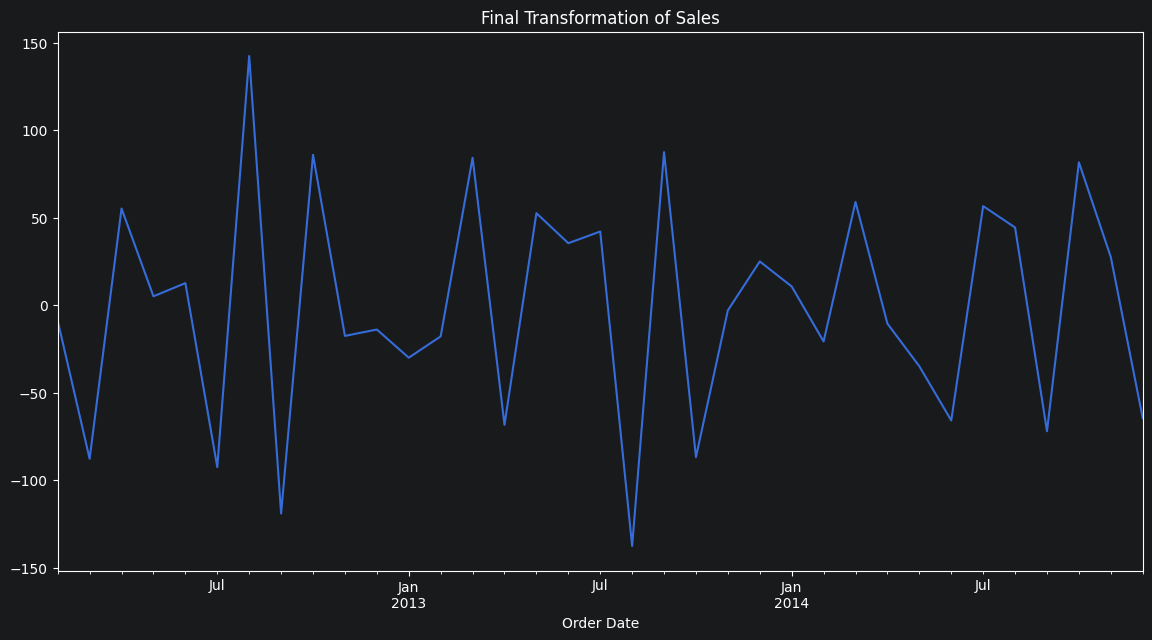

In [231]:
final_Series.plot(figsize=(14,7))
plt.title("Final Transformation of Sales")
plt.show()

### Now Check Stationary or Not

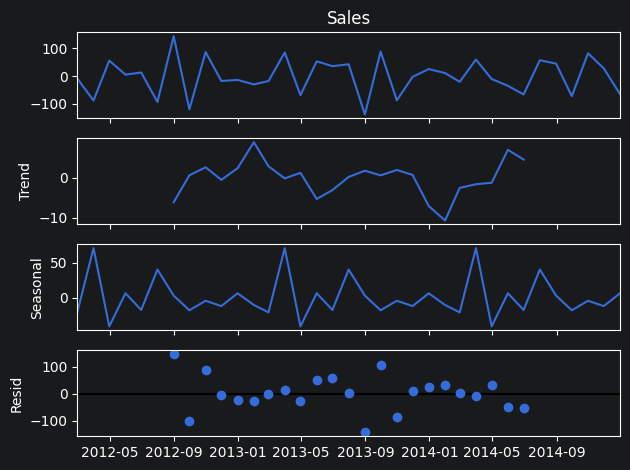

In [232]:
from statsmodels.tsa.seasonal import seasonal_decompose
decompose_plot = seasonal_decompose(final_Series).plot()

In [233]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(final_Series)
p_value = result[1]#second value is the p-value and is not less then 0.5 %
if p_value < 0.05:
    print(f"{result[1]} is less than 0.05 and it's Stationary data, Null Hypothesis is False")
else:
    print(f"{result[1]} is more than 0.05 and it's non-Stationary data, Null Hypothesis is True")

1.0996443857187938e-05 is less than 0.05 and it's Stationary data, Null Hypothesis is False


In [234]:
final_Series

Order Date
2012-02-29     -9.011792
2012-03-31    -87.782063
2012-04-30     55.188297
2012-05-31      5.025967
2012-06-30     12.555894
2012-07-31    -92.574971
2012-08-31    142.302605
2012-09-30   -119.075511
2012-10-31     85.852349
2012-11-30    -17.590987
2012-12-31    -13.950273
2013-01-31    -30.050980
2013-02-28    -17.861380
2013-03-31     84.150922
2013-04-30    -68.425895
2013-05-31     52.545090
2013-06-30     35.361374
2013-07-31     42.047675
2013-08-31   -137.635894
2013-09-30     87.398289
2013-10-31    -86.870712
2013-11-30     -3.011529
2013-12-31     24.940064
2014-01-31     10.651892
2014-02-28    -20.766348
2014-03-31     58.919778
2014-04-30    -10.587166
2014-05-31    -34.940131
2014-06-30    -65.895512
2014-07-31     56.553656
2014-08-31     44.332736
2014-09-30    -72.063417
2014-10-31     81.593061
2014-11-30     27.431163
2014-12-31    -64.520712
Freq: ME, Name: Sales, dtype: float64

### ACF & PACF Analysis for model Identification
- Determine p, q | q = order of MA = Moving Average
- Determine P, Q | p = Order of AR = Auto regressor

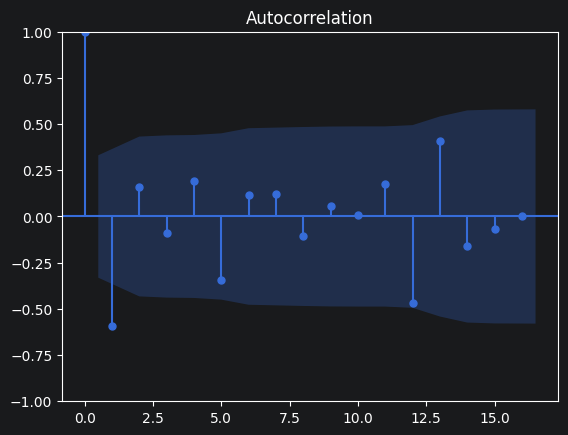

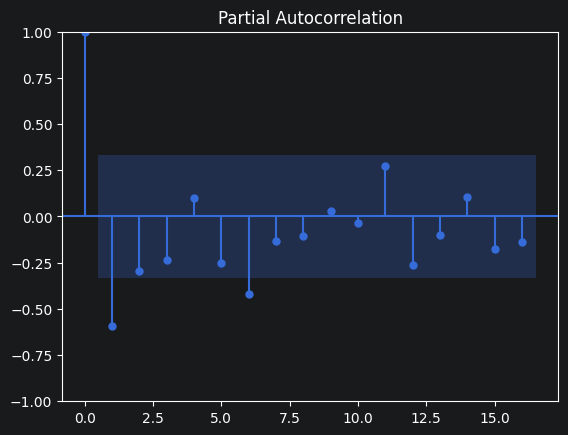

In [235]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(final_Series)
plot_pacf(final_Series); # lag number = k, for example k = 1 the lag = 1

### Find p,q and d | P, Q, D and s

In [236]:
# split rows into train and test
print(f"Total number of rows = {final_Series.shape}")
train_item = 35 * 0.8
test_item = 35 * 0.2
print(f"Number of row for training data = {train_item}")
print(f"Number of row for testing data = {test_item}")

train = final_Series[:28]
test = final_Series[28:]


Total number of rows = (35,)
Number of row for training data = 28.0
Number of row for testing data = 7.0


In [237]:
train

Order Date
2012-02-29     -9.011792
2012-03-31    -87.782063
2012-04-30     55.188297
2012-05-31      5.025967
2012-06-30     12.555894
2012-07-31    -92.574971
2012-08-31    142.302605
2012-09-30   -119.075511
2012-10-31     85.852349
2012-11-30    -17.590987
2012-12-31    -13.950273
2013-01-31    -30.050980
2013-02-28    -17.861380
2013-03-31     84.150922
2013-04-30    -68.425895
2013-05-31     52.545090
2013-06-30     35.361374
2013-07-31     42.047675
2013-08-31   -137.635894
2013-09-30     87.398289
2013-10-31    -86.870712
2013-11-30     -3.011529
2013-12-31     24.940064
2014-01-31     10.651892
2014-02-28    -20.766348
2014-03-31     58.919778
2014-04-30    -10.587166
2014-05-31    -34.940131
Freq: ME, Name: Sales, dtype: float64

In [238]:
test

Order Date
2014-06-30   -65.895512
2014-07-31    56.553656
2014-08-31    44.332736
2014-09-30   -72.063417
2014-10-31    81.593061
2014-11-30    27.431163
2014-12-31   -64.520712
Freq: ME, Name: Sales, dtype: float64

In [239]:
# d we already know first differencing and seasonal differencing | d = 1, D = 1
# s we know season = 12 coz of month wise data
# find p and P from PACF
# find q and Q from ACF

from statsmodels.tsa.arima.model import ARIMA
import itertools
from sklearn.metrics import *

p = range(0,8)
d = range(1,2)
q = range(0,8)

pdq = list(itertools.product(p,d,q))
rmse = []
order1 = []

for i in pdq:
  model = ARIMA(train, order = i)
  model_fit = model.fit()
  pred = model_fit.predict(start = len(train), end = len(train)+len(test)-1)
  error = np.sqrt(mean_squared_error(test, pred))
  order1.append(i)
  rmse.append(error)

results = pd.DataFrame(index = order1, data = rmse, columns = ['RMSE'])





C:\Users\User\PyCharmMiscProject\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\User\PyCharmMiscProject\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\User\PyCharmMiscProject\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\User\PyCharmMiscProject\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\User\PyC

In [240]:
results.sort_values(by= 'RMSE', ascending = True)

,RMSE
"(4, 1, 3)",48.742169
"(3, 1, 3)",48.766385
"(6, 1, 7)",55.988684
"(0, 1, 1)",61.325078
"(5, 1, 4)",62.785735
...,...
"(6, 1, 3)",86.379347
"(7, 1, 3)",88.348348
"(6, 1, 2)",89.629111
"(7, 1, 6)",106.292752


In [241]:
final_Series

Order Date
2012-02-29     -9.011792
2012-03-31    -87.782063
2012-04-30     55.188297
2012-05-31      5.025967
2012-06-30     12.555894
2012-07-31    -92.574971
2012-08-31    142.302605
2012-09-30   -119.075511
2012-10-31     85.852349
2012-11-30    -17.590987
2012-12-31    -13.950273
2013-01-31    -30.050980
2013-02-28    -17.861380
2013-03-31     84.150922
2013-04-30    -68.425895
2013-05-31     52.545090
2013-06-30     35.361374
2013-07-31     42.047675
2013-08-31   -137.635894
2013-09-30     87.398289
2013-10-31    -86.870712
2013-11-30     -3.011529
2013-12-31     24.940064
2014-01-31     10.651892
2014-02-28    -20.766348
2014-03-31     58.919778
2014-04-30    -10.587166
2014-05-31    -34.940131
2014-06-30    -65.895512
2014-07-31     56.553656
2014-08-31     44.332736
2014-09-30    -72.063417
2014-10-31     81.593061
2014-11-30     27.431163
2014-12-31    -64.520712
Freq: ME, Name: Sales, dtype: float64

In [242]:
ar = ARIMA(train, order = (4,1,0))
ar_result = ar.fit()
final_Series["predict_ar"] = ar_result.predict(start= len(train), end=len(train)+len(test)-1, dynamic=False)

In [249]:
plt.plot(test["Sales"], label= "Original Data")
plt.plot(final_Series["predict_ar"], label= "Predicted Data")
plt.legend()
plt.show()

KeyError: 'Sales'